In [1]:
import zipfile
from pathlib import Path

import pandas as pd
import geopandas as gpd
import fiona

In [2]:
import matplotlib.pyplot as plt


In [3]:
kmz_path = Path("/content/sample_data/BC Fire Points 2024.kmz")
out_dir = kmz_path.with_suffix("")  #
out_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(kmz_path, "r") as z:
    kml_files = [n for n in z.namelist() if n.lower().endswith(".kml")]
    print("KML inside KMZ:", kml_files)

    z.extractall(out_dir)


kml_path = out_dir / ("doc.kml" if (out_dir / "doc.kml").exists() else kml_files[0])
kml_path


KML inside KMZ: ['doc.kml']


PosixPath('/content/sample_data/BC Fire Points 2024/doc.kml')

In [4]:
# Enable driver (works in many environments)
fiona.drvsupport.supported_drivers["KML"] = "rw"

gdf = gpd.read_file(kml_path, driver="KML")
gdf.head()


,id,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,snippet,geometry
0,ID_00242,C10084,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",NaT,NaT,NaT,None,-1,0,-1,NaN,None,,POINT Z (-124.49087 53.08744 0)
1,ID_01268,C10089,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",NaT,NaT,NaT,None,-1,0,-1,NaN,None,,POINT Z (-122.52388 53.05767 0)
2,ID_00064,C10110,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",NaT,NaT,NaT,None,-1,0,-1,NaN,None,,POINT Z (-122.53103 52.77461 0)
3,ID_01261,C10121,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",NaT,NaT,NaT,None,-1,0,-1,NaN,None,,POINT Z (-122.50732 52.89251 0)
4,ID_00269,C10136,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",NaT,NaT,NaT,None,-1,0,-1,NaN,None,,POINT Z (-122.96009 52.98256 0)


In [5]:
print("Rows:", len(gdf))
print("CRS:", gdf.crs)
print("Geometry types:\n", gdf.geometry.geom_type.value_counts(dropna=False))


display(gdf.describe(include="all").T)


na = gdf.isna().mean().sort_values(ascending=False)
display(na[na > 0].head(20))


dups = gdf.duplicated(subset=["geometry"]).sum()
print("Exact duplicate geometries:", dups)


Rows: 1698
CRS: EPSG:4326
Geometry types:
 Point    1698
Name: count, dtype: int64


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,1698,1698,ID_00916,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,1698,1698,VA2204,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,1698,1698,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,0,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaT,NaT,NaN
begin,0,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaT,NaT,NaN
end,0,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaT,NaT,NaN
altitudeMode,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tessellate,1698.0,NaN,NaN,NaN,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0
extrude,1698.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
visibility,1698.0,NaN,NaN,NaN,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0


,0
begin,1.0
timestamp,1.0
end,1.0
icon,1.0
drawOrder,1.0
altitudeMode,1.0


Exact duplicate geometries: 0


In [6]:

if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)

gdf_ll = gdf.to_crs(epsg=4326)
gdf_ll["lon"] = gdf_ll.geometry.x
gdf_ll["lat"] = gdf_ll.geometry.y

gdf_ll[["lon","lat"]].head()


,lon,lat
0,-124.490867,53.087439
1,-122.523884,53.057673
2,-122.531033,52.774606
3,-122.507316,52.892506
4,-122.960095,52.982565


In [7]:
gdf_ll[["lon","lat"]].describe()


,lon,lat
count,1698.000000,1698.000000
mean,-120.941264,52.260589
std,2.847868,2.795359
min,-133.412415,48.466839
25%,-122.529246,50.178339
50%,-120.790457,51.440314
75%,-118.961899,53.715302
max,-114.504347,59.946089


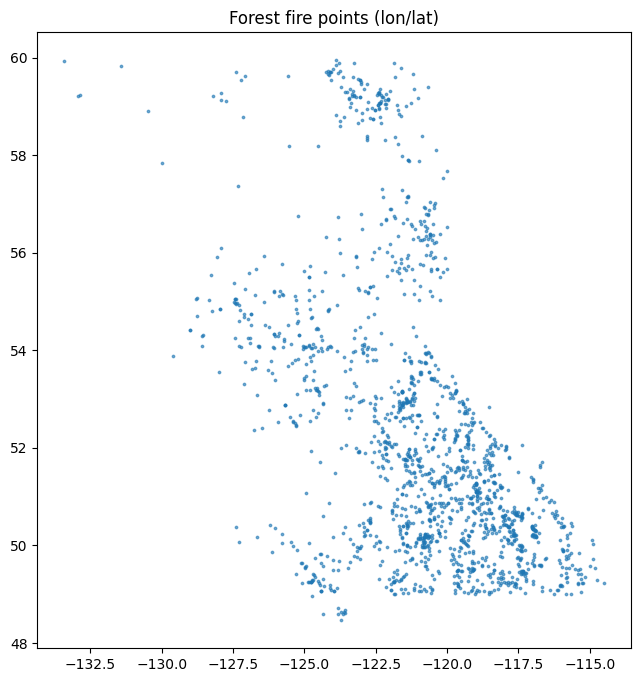

In [8]:
ax = gdf_ll.plot(figsize=(8, 8), markersize=3, alpha=0.6)
ax.set_title("Forest fire points (lon/lat)")
plt.show()


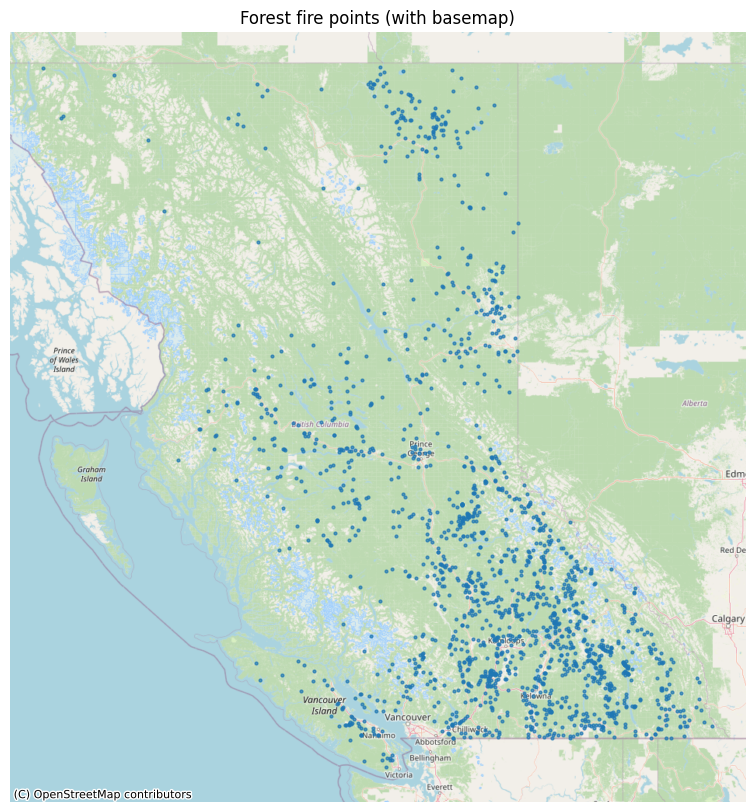

In [11]:
import contextily as ctx

gdf_3857 = gdf_ll.to_crs(epsg=3857)
ax = gdf_3857.plot(figsize=(10, 10), markersize=4, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title("Forest fire points (with basemap)")
plt.show()


In [ ]:
!pip install pyproj

## Applying Functions: `.apply()`, `.map()`, `.lambda`

In [12]:
import folium

center = [gdf_ll["lat"].median(), gdf_ll["lon"].median()]
m = folium.Map(location=center, zoom_start=5, tiles="OpenStreetMap")

for _, r in gdf_ll.head(5000).iterrows():  # cap for performance
    folium.CircleMarker(
        location=[r["lat"], r["lon"]],
        radius=2, weight=0, fill=True, fill_opacity=0.6
    ).add_to(m)

m


## Transforming Data: `.pivot()`, `.melt()`, `.stack()`, `.unstack()`

In [15]:
# Find likely datetime columns
candidates = [c for c in gdf.columns if any(k in c.lower() for k in ["date","time","dt","timestamp"])]
candidates


['timestamp']

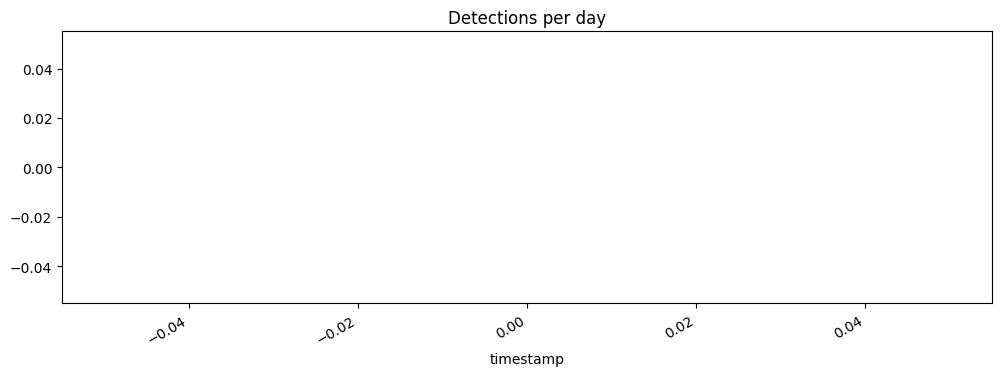

In [14]:
date_col = candidates[0]  # choose the right one
df = gdf_ll.copy()
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

daily = df.dropna(subset=[date_col]).groupby(df[date_col].dt.date).size()
daily.plot(figsize=(12,4), title="Detections per day")
plt.show()
